In [1]:
!pip install numpy matplotlib

In [2]:
import numpy as np

class GridWorldEnv:
    def __init__(self, width: int = 6, height: int = 6):
        self.width = width
        self.height = height
        self.grid = np.zeros((height, width), dtype=int)
        self.start_pos = (0, 0)
        self.goal_pos = (5, 4)
        self.grid[0, 0] = 3
        self.grid[4, 5] = 2
        self.grid[0, 3] = 1
        self.grid[1, 3] = 1
        self.grid[3, 1] = 1
        self.grid[4, 1] = 1
        self.grid[1, 1] = -1
        self.grid[3, 3] = -1
        self.agent_pos = self.start_pos

    @property
    def n_states(self) -> int:
        return self.width * self.height

    @property
    def n_actions(self) -> int:
        return 4

    def reset(self) -> int:
        self.agent_pos = self.start_pos
        return self._pos_to_state(self.agent_pos)

    def step(self, action: int):
        x, y = self.agent_pos
        new_x, new_y = x, y
        if action == 0:
            new_y -= 1
        elif action == 1:
            new_x += 1
        elif action == 2:
            new_y += 1
        elif action == 3:
            new_x -= 1
        if not (0 <= new_x < self.width and 0 <= new_y < self.height):
            reward = -5.0
            done = False
            return self._pos_to_state(self.agent_pos), reward, done
        cell_value = self.grid[new_y, new_x]
        if cell_value == 1:
            reward = -5.0
            done = False
            return self._pos_to_state(self.agent_pos), reward, done
        self.agent_pos = (new_x, new_y)
        if cell_value == 2:
            reward = 10.0
            done = True
        elif cell_value == -1:
            reward = -10.0
            done = True
        else:
            reward = -1.0
            done = False
        return self._pos_to_state(self.agent_pos), reward, done

    def _pos_to_state(self, pos):
        x, y = pos
        return y * self.width + x


class QLearningAgent:
    def __init__(
        self,
        n_states: int,
        n_actions: int,
        learning_rate: float = 0.1,
        gamma: float = 0.99,
        epsilon: float = 1.0,
        epsilon_min: float = 0.05,
        epsilon_decay: float = 0.995,
    ):
        self.n_states = n_states
        self.n_actions = n_actions
        self.lr = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table = np.zeros((n_states, n_actions), dtype=np.float32)

    def select_action(self, state: int) -> int:
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.q_table[state]))

    def update(self, state: int, action: int, reward: float, next_state: int, done: bool):
        best_next_q = 0.0 if done else np.max(self.q_table[next_state])
        td_target = reward + self.gamma * best_next_q
        td_error = td_target - self.q_table[state, action]
        self.q_table[state, action] += self.lr * td_error

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

Episode 50/800, total_reward=-16.0, epsilon=0.778
Episode 100/800, total_reward=-29.0, epsilon=0.606
Episode 150/800, total_reward=-10.0, epsilon=0.471
Episode 200/800, total_reward=0.0, epsilon=0.367
Episode 250/800, total_reward=2.0, epsilon=0.286
Episode 300/800, total_reward=2.0, epsilon=0.222
Episode 350/800, total_reward=0.0, epsilon=0.173
Episode 400/800, total_reward=-11.0, epsilon=0.135
Episode 450/800, total_reward=-2.0, epsilon=0.105
Episode 500/800, total_reward=2.0, epsilon=0.082
Episode 550/800, total_reward=2.0, epsilon=0.063
Episode 600/800, total_reward=2.0, epsilon=0.050
Episode 650/800, total_reward=2.0, epsilon=0.050
Episode 700/800, total_reward=0.0, epsilon=0.050
Episode 750/800, total_reward=2.0, epsilon=0.050
Episode 800/800, total_reward=2.0, epsilon=0.050
Saved q_table.npy and q_table.csv


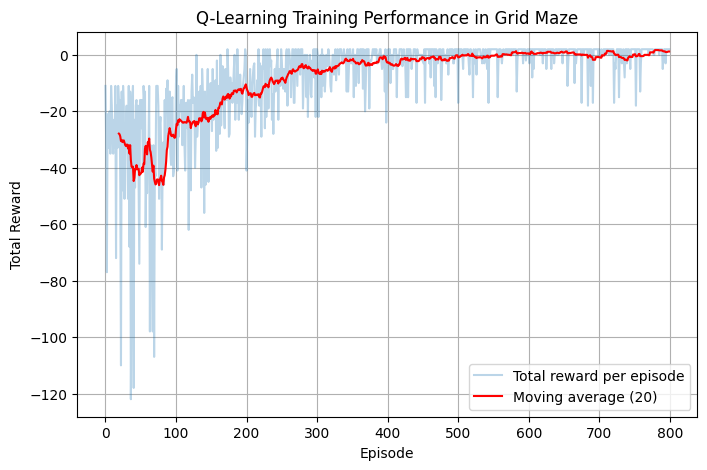

In [3]:
import matplotlib.pyplot as plt

env = GridWorldEnv()
agent = QLearningAgent(
    n_states=env.n_states,
    n_actions=env.n_actions,
    learning_rate=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
)

num_episodes = 800
max_steps_per_episode = 50

episode_rewards = []

for episode in range(1, num_episodes + 1):
    state = env.reset()
    total_reward = 0.0

    for step in range(max_steps_per_episode):
        action = agent.select_action(state)
        next_state, reward, done = env.step(action)
        agent.update(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        if done:
            break

    agent.decay_epsilon()
    episode_rewards.append(total_reward)

    if episode % 50 == 0:
        print(
            f"Episode {episode}/{num_episodes}, "
            f"total_reward={total_reward:.1f}, epsilon={agent.epsilon:.3f}"
        )

np.save("q_table.npy", agent.q_table)
np.savetxt("q_table.csv", agent.q_table, delimiter=",")
print("Saved q_table.npy and q_table.csv")

window = 20
rewards_array = np.array(episode_rewards, dtype=np.float32)
moving_avg = np.convolve(
    rewards_array,
    np.ones(window, dtype=np.float32) / window,
    mode="valid",
)

plt.figure(figsize=(8, 5))
plt.plot(episode_rewards, label="Total reward per episode", alpha=0.3)
plt.plot(range(window - 1, num_episodes), moving_avg, label=f"Moving average ({window})", color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning Training Performance in Grid Maze")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
agent.epsilon = 0.0

state = env.reset()
path_states = [state]
total_reward_demo = 0.0

for step in range(max_steps_per_episode):
    action = agent.select_action(state)
    next_state, reward, done = env.step(action)
    path_states.append(next_state)
    total_reward_demo += reward
    state = next_state
    if done:
        break

print("Greedy path states:", path_states)
print("Total reward on greedy path:", total_reward_demo)
print("Length of path:", len(path_states))

Greedy path states: [0, 6, 12, 13, 14, 20, 26, 27, 28, 29]
Total reward on greedy path: 2.0
Length of path: 10
